# Test the car-price prediction model

This notebook loads the model exported by **`autoresearch-car-model.py`**
(`car-price-prediction-model.pt`) and checks its accuracy on a **random chunk of
held-out data** — rows the model never saw while training.

**Why this is honest:** the training script splits the data deterministically
(fixed `SEED`) into train / validation. We re-derive that exact split here and
draw our random chunk from the **validation** rows only, so the MAE / RMSE / MAPE
below reflect real generalization, not memorized training examples.

Run all cells. Re-run the *random chunk* cell to score a different sample.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# --- Config -----------------------------------------------------------------
MODEL_PATH   = "car-price-prediction-model.pt"   # bundle exported by the trainer
TRAIN_SCRIPT = "autoresearch-car-model.py"       # source of the pipeline + model code
CHUNK_SIZE   = 500     # how many held-out cars to score (capped at val-set size)
CHUNK_SEED   = None    # set to an int for a reproducible chunk; None = fresh each run

device = torch.device("cpu")   # inference is tiny and deterministic on CPU

# Import the training module (its filename has dashes, so load it by path).
spec = importlib.util.spec_from_file_location("autoresearch_car_model", TRAIN_SCRIPT)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
print("Loaded training code from", TRAIN_SCRIPT)

Loaded training code from autoresearch-car-model.py


In [2]:
# Load the exported bundle. weights_only=False because it carries the feature
# pipeline (numpy arrays + python dicts), not just tensors.
bundle = torch.load(MODEL_PATH, weights_only=False)

print(f"Model bundle : {MODEL_PATH}")
print(f"  trained on : {bundle['data_path']}")
print(f"  split seed : {bundle['seed']}   val_frac: {bundle['val_frac']}   ref_year: {bundle['ref_year']}")
print(f"  hidden MLP : {tuple(bundle['hidden'])}   dropout: {bundle['dropout']}")
print(f"  categorical: {bundle['categorical']}")
print(f"  numeric    : {bundle['numeric']}")
print()
print("Score recorded at export time (full validation split):")
print(f"  MAE  : EUR {bundle['val_mae']:,.0f}")
print(f"  RMSE : EUR {bundle['val_rmse']:,.0f}")
print(f"  MAPE : {bundle['val_mape']:.1f}%")

Model bundle : car-price-prediction-model.pt
  trained on : merged_cars.csv
  split seed : 42   val_frac: 0.3   ref_year: 2026
  hidden MLP : (256, 128)   dropout: 0.2
  categorical: ['brand', 'model', 'fuel', 'transmission', 'body_type']
  numeric    : ['age', 'mileage_km', 'model']

Score recorded at export time (full validation split):
  MAE  : EUR 2,161
  RMSE : EUR 5,381
  MAPE : 17.3%


In [ ]:
# Re-derive the exact deterministic split, then REBUILD the feature pipeline by
# re-fitting it on the TRAIN rows. The exported bundle carries only a SUBSET of the
# pipeline statistics, so instead of restoring them we RE-FIT. fit() is fully
# deterministic (the split is seed-fixed and it only sorts/aggregates/takes medians),
# so it reproduces EXACTLY the pipeline the model trained with -- vocab, the
# mileage/displacement/power medians, standardization, the title-parsed numeric
# features and the derived `engine_code` -- as long as the CSV on disk is the one it
# was trained on, which this notebook already assumes (it scores val rows from it).
data_path = bundle["data_path"]
if not Path(data_path).exists():
    data_path = "merged_cars.csv"   # fall back to the default dataset
df, train_idx, val_idx = mod.load_and_split(data_path)
pipe = mod.FeaturePipeline().fit(df.iloc[train_idx])

# Sanity checks: the loaded code + data must agree with how the model was trained.
assert list(bundle["categorical"]) == list(mod.CATEGORICAL), "CATEGORICAL drifted vs the trained model"
assert int(bundle["ref_year"]) == int(mod.REF_YEAR), "REF_YEAR drifted vs the trained model"
assert list(pipe.cardinalities) == list(bundle["cardinalities"]), (
    "Re-fit cardinalities differ from the exported model -> merged_cars.csv changed "
    "since training. Retrain (uv run autoresearch-car-model.py) before testing."
)

# Rebuild whatever the trainer exported and load the weights. Three shapes are
# possible depending on the hyperparameters at train time:
#   * CatBoost      -> MODEL="catboost": the native model rides under "catboost_model"
#   * EnsembleModel -> N_SEEDS>1: state_dict keys are prefixed "members.<i>."
#   * CarPriceNet   -> a single net (N_SEEDS==1)
def build_model(state_dict):
    if "catboost_model" in state_dict:
        return mod.CatBoostModel(state_dict["catboost_model"])
    new_net = lambda: mod.CarPriceNet(
        pipe.cardinalities, pipe.n_numeric,
        hidden=tuple(bundle["hidden"]), dropout=bundle["dropout"],
    )
    member_ids = sorted({int(k.split(".")[1]) for k in state_dict if k.startswith("members.")})
    net = mod.EnsembleModel([new_net() for _ in member_ids]) if member_ids else new_net()
    net.load_state_dict(state_dict)
    return net.to(device).eval()

model = build_model(bundle["state_dict"])
if isinstance(model, mod.CatBoostModel):
    kind, size, unit = "CatBoost", int(model.cb.tree_count_), "trees"
elif hasattr(model, "members"):
    kind, size, unit = f"EnsembleModel ({len(model.members)} nets)", sum(p.numel() for p in model.parameters()), "parameters"
else:
    kind, size, unit = "CarPriceNet", sum(p.numel() for p in model.parameters()), "parameters"
print(f"Rebuilt {kind}: {size:,} {unit}, ready for inference.")

## Load a random chunk of held-out data and score it

In [4]:
# df / train_idx / val_idx were derived in the rebuild cell above (same deterministic
# split the model trained against). Take a RANDOM chunk from the held-out validation
# rows only -- cars the model never saw in training.
rng = np.random.default_rng(CHUNK_SEED)
n = min(CHUNK_SIZE, len(val_idx))
chunk_idx = rng.choice(val_idx, size=n, replace=False)

print(f"Dataset      : {data_path}  ({len(df):,} clean rows)")
print(f"Held-out val : {len(val_idx):,} rows")
print(f"Random chunk : {n:,} rows scored this run")

Dataset      : merged_cars.csv  (31,015 clean rows)
Held-out val : 9,304 rows
Random chunk : 500 rows scored this run


In [5]:
mae, rmse, mape, preds = mod.evaluate(model, pipe, df, chunk_idx, device)
actual = df.iloc[chunk_idx][mod.TARGET].to_numpy(dtype=float)

print("=== Accuracy on the random held-out chunk ===")
print(f"  MAE            : EUR {mae:,.0f}   (typical error per car)")
print(f"  RMSE           : EUR {rmse:,.0f}   (penalizes big misses)")
print(f"  MAPE           : {mape:.1f}%   (average % off)")
print(f"  median |error| : EUR {np.median(np.abs(preds - actual)):,.0f}")
print(f"  within 10%     : {np.mean(np.abs(preds - actual) / actual <= 0.10) * 100:.0f}% of cars")
print(f"  within 20%     : {np.mean(np.abs(preds - actual) / actual <= 0.20) * 100:.0f}% of cars")

=== Accuracy on the random held-out chunk ===
  MAE            : EUR 2,463   (typical error per car)
  RMSE           : EUR 8,093   (penalizes big misses)
  MAPE           : 16.0%   (average % off)
  median |error| : EUR 1,088
  within 10%     : 49% of cars
  within 20%     : 78% of cars


In [6]:
# Per-car table: predicted vs actual, with absolute and percentage error.
results = df.iloc[chunk_idx][["build_year", "brand", "model", "fuel", "transmission", "mileage_km"]].copy()
results["actual_eur"]    = actual.round(0)
results["predicted_eur"] = preds.round(0)
results["error_eur"]     = (preds - actual).round(0)
results["abs_pct_error"] = (np.abs(preds - actual) / actual * 100).round(1)
results = results.reset_index(drop=True)

print("Sample predictions:")
display(results.head(10))
print("Worst misses (largest % error):")
display(results.sort_values("abs_pct_error", ascending=False).head(10))

Sample predictions:


,build_year,brand,model,fuel,transmission,mileage_km,actual_eur,predicted_eur,error_eur,abs_pct_error
0,2022.0,Cupra,Formentor,Hybride Elektrisch/Benzine,Automaat,50514.0,29995.0,28002.0,-1993.0,6.6
1,2022.0,Toyota,Corolla,Hybride Elektrisch/Benzine,Automaat,86518.0,20990.0,21657.0,667.0,3.2
2,2018.0,BMW,3-Serie,Benzine,Automaat,144758.0,18950.0,22042.0,3092.0,16.3
3,2024.0,Renault,Master,Diesel,Handgeschakeld,33846.0,38900.0,38347.0,-553.0,1.4
4,2022.0,Opel,Astra,Hybride Elektrisch/Benzine,Automaat,52998.0,23035.0,21807.0,-1228.0,5.3
5,2023.0,Cupra,Formentor,Hybride Elektrisch/Benzine,Automaat,83285.0,28499.0,26977.0,-1522.0,5.3
6,2014.0,Renault,Scénic,Benzine,Handgeschakeld,177302.0,6700.0,4871.0,-1829.0,27.3
7,2020.0,Opel,Corsa,Benzine,Handgeschakeld,154308.0,7999.0,8518.0,519.0,6.5
8,2016.0,Audi,A1,Benzine,Handgeschakeld,NaN,10750.0,11090.0,340.0,3.2
9,2021.0,Kia,Niro,Elektrisch,Automaat,46409.0,20900.0,26879.0,5979.0,28.6


Worst misses (largest % error):


,build_year,brand,model,fuel,transmission,mileage_km,actual_eur,predicted_eur,error_eur,abs_pct_error
153,2010.0,Mazda,6,Benzine,Automaat,NaN,4750.0,11611.0,6861.0,144.4
223,2006.0,Opel,Zafira,Benzine,Handgeschakeld,NaN,1100.0,2547.0,1447.0,131.6
443,2006.0,Ford,S-Max,Benzine,Handgeschakeld,NaN,1300.0,2991.0,1691.0,130.1
302,2015.0,Opel,Astra,Diesel,Handgeschakeld,334824.0,1500.0,3217.0,1717.0,114.4
11,2018.0,Renault,Mégane,Benzine,Handgeschakeld,18550.0,5999.0,12400.0,6401.0,106.7
459,2010.0,Volvo,V50,Diesel,Handgeschakeld,290550.0,1250.0,2448.0,1198.0,95.8
113,2013.0,Ford,Grand C-Max,Diesel,Handgeschakeld,256318.0,2350.0,4409.0,2059.0,87.6
26,1992.0,Volkswagen,Polo,Benzine,Handgeschakeld,NaN,11300.0,1519.0,-9781.0,86.6
258,2004.0,Alfa Romeo,GT,Benzine,Handgeschakeld,49628.0,29950.0,4149.0,-25801.0,86.1
107,2016.0,Mercedes-Benz,B-Klasse,CNG (Aardgas),Handgeschakeld,383200.0,3675.0,6743.0,3068.0,83.5


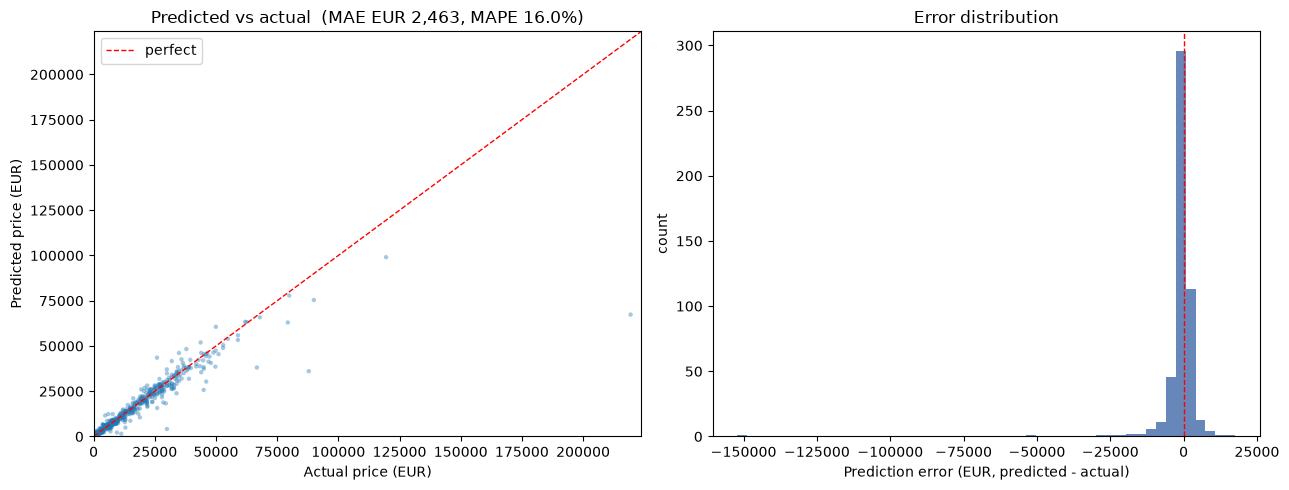

In [7]:
errors = preds - actual

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual, with the perfect-prediction diagonal.
ax = axes[0]
ax.scatter(actual, preds, s=10, alpha=0.4, edgecolor="none")
lim = [0, max(actual.max(), preds.max()) * 1.02]
ax.plot(lim, lim, "r--", lw=1, label="perfect")
ax.set(xlim=lim, ylim=lim, xlabel="Actual price (EUR)", ylabel="Predicted price (EUR)",
       title=f"Predicted vs actual  (MAE EUR {mae:,.0f}, MAPE {mape:.1f}%)")
ax.legend()

# Error distribution.
ax = axes[1]
ax.hist(errors, bins=50, color="#4c72b0", alpha=0.85)
ax.axvline(0, color="r", ls="--", lw=1)
ax.set(xlabel="Prediction error (EUR, predicted - actual)", ylabel="count",
       title="Error distribution")

plt.tight_layout()
plt.show()

## Refreshing the model

The model file is re-exported every time you train:

```bash
uv run autoresearch-car-model.py                    # full 60s budget
uv run autoresearch-car-model.py --time-budget 15   # quick
```

That overwrites `car-price-prediction-model.pt`; re-run this notebook to test the
new version. Tweak `CHUNK_SIZE` to score more/fewer cars, or set `CHUNK_SEED` to a
fixed integer to score the exact same chunk every run.